In [1]:
import mmml
from mmml.pycharmmInterface import import_pycharmm
from mmml.pycharmmInterface.import_pycharmm import reset_block, pycharmm_quiet, pycharmm_soft
pycharmm_quiet()
from mmml.pycharmmInterface import utils, setupRes
from mmml.pycharmmInterface.utils import view_pycharmm_state, get_Z_from_psf

/home/ericb/mmml/mmml/data/charmm/top_all36_cgenff.rtf
/home/ericb/mmml/mmml/data/charmm/par_all36_cgenff.prm
CHARMM_HOME /home/ericb/mmml/setup/charmm
CHARMM_LIB_DIR /home/ericb/mmml/setup/charmm
  
 CHARMM>     BLOCK
 WARNING from DECODI -- Zero length string being converted to 0
 Block structure initialized with   3 blocks.
 All atoms have been assigned to block 1.
 All interaction coefficients have been set to unity.
  Setting number of block exclusions nblock_excldPairs=0
  
  BLOCK>            CALL 1 SELE ALL END
 SELRPN>      0 atoms have been selected out of      0
 The selected atoms have been reassigned to block   1
  
  BLOCK>              COEFF 1 1 1.0
  
  BLOCK>            END
 Matrix of Interaction Coefficients
 
    1.00000
    1.00000   1.00000
    1.00000   1.00000   1.00000
 Matrix of BOND Interaction Coefficients
 
    1.00000
    1.00000   1.00000
    1.00000   1.00000   1.00000
 Matrix of ANGLE Interaction Coefficients
 
    1.00000
    1.00000   1.00000
    1.000

In [79]:
import pycharmm
from pycharmm import energy

In [80]:
reset_block()
setupRes.main("BENZ")

***** Generating residue from residue name (BENZ) *****
***** Generating residue *****

 DRUDES PARTICLES WILL BE GENERATED AUTOMATICALLY FOR ALL ATOMS WITH NON-ZERO ALPHA
 Thole-type dipole screening, Slater-Delta shape {S(u) = 1 - (1+u/2)*exp(-u)}, default radius =  1.300000
***** Generating coordinates *****

          COORDINATE FILE MODULE
        12  EXT
         1         1  BENZ      CG           9999.0000000000     9999.0000000000     9999.0000000000  BENZ      1               0.0000000000
         2         1  BENZ      HG           9999.0000000000     9999.0000000000     9999.0000000000  BENZ      1               0.0000000000
         3         1  BENZ      CD1          9999.0000000000     9999.0000000000     9999.0000000000  BENZ      1               0.0000000000
         4         1  BENZ      HD1          9999.0000000000     9999.0000000000     9999.0000000000  BENZ      1               0.0000000000
         5         1  BENZ      CD2          9999.0000000000     9999.000

Atoms(symbols='CHCHCHCHCHCH', pbc=False)

In [81]:
resid = "BENZ"
pycharmm.read.sequence_string(resid)
pycharmm.gen.new_segment(seg_name=resid, setup_ic=True)
pycharmm.ic.prm_fill(replace_all=True)


          RESIDUE SEQUENCE --     1 RESIDUES
          BENZ    
 NO PATCHING WILL BE DONE ON THE FIRST RESIDUE
 NO PATCHING WILL BE DONE ON THE LAST  RESIDUE
 AUTGEN: Autogenerating specified angles and dihedrals.
 GENPSF> Segment   2 has been generated. Its identifier is BENZ.
 PSFSUM> PSF modified: NONBOND lists and IMAGE atoms cleared.
 PSFSUM> Summary of the structure file counters :
         Number of segments      =        2   Number of residues   =        2
         Number of atoms         =       24   Number of groups     =        2
         Number of bonds         =       24   Number of angles     =       36
         Number of dihedrals     =       48   Number of impropers  =        0
         Number of cross-terms   =        0   Number of autogens   =        0
         Number of HB acceptors  =        0   Number of HB donors  =        0
         Number of NB exclusions =        0   Total charge =    0.00000


In [82]:
pycharmm.coor.show()


          COORDINATE FILE MODULE
 TITLE>  * EXECUTING CHARMM SCRIPT FROM PYTHON
 TITLE>  *  DATE:     3/27/26     12: 7:46      CREATED BY USER: ericb
 TITLE>  *
        24  EXT
         1         1  BENZ      CG             -0.3322279139        0.2986599336       -0.3804148062  BENZ      1               0.0000000000
         2         1  BENZ      HG             -1.1274021743        0.2361441260       -1.1087287970  BENZ      1               0.0000000000
         3         1  BENZ      CD1            -0.1314198958        1.4849124090        0.3397503355  BENZ      1               0.0000000000
         4         1  BENZ      HD1            -0.7729056427        2.3377719375        0.1637043900  BENZ      1               0.0000000000
         5         1  BENZ      CD2             0.5005002839       -0.8073844869       -0.1555560109  BENZ      1               0.0000000000
         6         1  BENZ      HD2             0.3474402550       -1.7191185354       -0.7097346396  BENZ      1   

In [83]:
positions = pycharmm.coor.get_positions()

In [305]:
import numpy as np
positions_np = positions.to_numpy()
positions_np_copy = np.zeros_like(positions_np)
positions_np_copy[:12] = positions_np[:12]
positions_np_copy[12:] = positions_np[:12]

positions_np_copy[12:,0] += 10
positions_np_copy
positions[['x', 'y', 'z']] = positions_np_copy
pycharmm.coor.set_positions(positions)
setupRes.mini(nbxmod=5)

***** Minimizing *****


In [397]:
pycharmm_soft()

In [402]:
setupRes.mini(nbxmod=1)

***** Minimizing *****


In [403]:
pycharmm.energy.show()

In [404]:
view_pycharmm_state()

In [405]:
pycharmm.coor.show()


          COORDINATE FILE MODULE
        24  EXT
         1         1  BENZ      CG             -1.2983539025       -8.2729455127       -3.9661293260  BENZ      1               0.0000000000
         2         1  BENZ      HG             -0.6007046433       -9.0772067867       -3.7974217068  BENZ      1               0.0000000000
         3         1  BENZ      CD1            -2.2423628883       -8.3663482877       -4.9996347461  BENZ      1               0.0000000000
         4         1  BENZ      HD1            -2.2697211695       -9.2453917338       -5.6262554055  BENZ      1               0.0000000000
         5         1  BENZ      CD2            -1.2618208282       -7.1316656478       -3.1536653224  BENZ      1               0.0000000000
         6         1  BENZ      HD2            -0.5363879308       -7.0575825090       -2.3559071530  BENZ      1               0.0000000000
         7         1  BENZ      CE1            -3.1490045392       -7.3224078012       -5.2144921232  BE

In [406]:
pycharmm.write.coor_pdb("benz_dimer.pdb")

In [407]:
import ase
import pandas as pd
atoms = ase.io.read("benz_dimer.pdb")

In [408]:
R = atoms.get_positions()
Z= get_Z_from_psf()
atoms = ase.Atoms(atoms)

In [409]:
ase.io.write("benz_dimer.xyz", atoms)

In [410]:
from mmml.interfaces.chemcoordInterface import interface
from mmml.interfaces.chemcoordInterface.interface import patch_chemcoord_for_pandas3
patch_chemcoord_for_pandas3()
import chemcoord as cc

In [411]:
cc_mol_xyz = cc.Cartesian.read_xyz("benz_dimer.xyz")
cc_mol_xyz

,atom,x,y,z
0,C,-1.298,-8.273,-3.966
1,Hg,-0.601,-9.077,-3.797
2,Cd,-2.242,-8.366,-5.000
3,H,-2.270,-9.245,-5.626
4,Cd,-1.262,-7.132,-3.154
5,H,-0.536,-7.058,-2.356
6,Ce,-3.149,-7.322,-5.214
7,He,-3.882,-7.395,-6.011
8,Ce,-2.170,-6.083,-3.373
9,He,-2.146,-5.207,-2.745


In [412]:


import sympy

sympy.init_printing()
ba = sympy.Symbol("ba")
bb = sympy.Symbol("bb")
aa = sympy.Symbol("aa")
ab = sympy.Symbol("ab")
da = sympy.Symbol("da")
db = sympy.Symbol("db")

ba_val = 5
bb_val = 5
aa_val = 90
ab_val = -90
da_val = 0
db_val = 0

zmat1 = fragments[0].to_zmat()
zmat2 = zmat1.copy()

zmat1.safe_loc[zmat1.index[0], "bond"] = ba
zmat1.safe_loc[zmat1.index[0], "angle"] = aa
zmat1.safe_loc[zmat1.index[0], "dihedral"] = da

zmat2.safe_loc[zmat2.index[0], "bond"] = bb
zmat2.safe_loc[zmat2.index[0], "angle"] = ab
zmat2.safe_loc[zmat2.index[0], "dihedral"] = db

/home/ericb/mmml/.venv/lib/python3.13/site-packages/chemcoord/cartesian_coordinates/_cartesian_class_get_zmat.py:734: DeprecationWarning: Will be removed in the future. Please use give_zmat.
  warnings.warn(message, DeprecationWarning)


In [413]:
zmat1

,atom,b,a,d,bond,angle,dihedral
2,Cd,origin,e_z,e_x,$ba$,$aa$,$da$
1,Hg,2,e_z,e_x,2.156604,77.44364,-77.871898
4,Cd,1,2,e_x,2.156134,68.519521,-14.873688
6,Ce,4,1,2,2.803322,85.744817,-0.019694
8,Ce,6,4,1,2.427895,30.028706,-179.963551
0,C,8,6,4,2.429691,59.993514,0.032253
3,H,6,4,1,2.156491,85.718778,0.0286
5,H,8,6,4,2.15668,115.672357,0.036058
7,He,6,4,1,1.080199,179.960164,52.713848
10,C,8,6,4,1.400986,29.964896,-179.896281


In [912]:
ba_vals = np.arange(8, 11, 2)
bb_vals = np.arange(6, 9, 2)
aa_vals = np.arange(0, 90, 33)
ab_vals = np.arange(-90, 0, 20)
da_vals = np.arange(0, 175, 20)
db_vals = np.arange(-175, 0, 45)

In [945]:
len(ba_vals) , len(db_vals) , len(bb_vals) ,  len(aa_vals) , len(ab_vals) ,  len(da_vals)

In [920]:
len(ba_vals) *  len(db_vals) * len(bb_vals) *  len(aa_vals) * len(ab_vals) *  len(da_vals)

In [921]:
view_pycharmm_state()

In [922]:
np.random.normal(size=(10, 3))/100

array([[-0.00638588,  0.02086814,  0.01783899],
       [-0.0108207 ,  0.0165821 , -0.01127208],
       [-0.0061787 , -0.01211344,  0.01483184],
       [-0.00700411,  0.0037796 ,  0.01038214],
       [ 0.00707272, -0.0052562 , -0.00143402],
       [-0.00990442,  0.01562324,  0.02293051],
       [ 0.01441716, -0.01206189, -0.00522692],
       [-0.00882764,  0.0103932 ,  0.0039224 ],
       [ 0.00431113, -0.0052326 ,  0.00906949],
       [-0.00950493,  0.02227784,  0.00325539]])

In [923]:
def make_conf(ba_val, bb_val, aa_val, ab_val, da_val, db_val):


    a = zmat1.subs(
        ba, ba_val + np.random.normal()/100 ).subs(
        aa, aa_val + np.random.normal()).subs(
        da, da_val + np.random.normal()).get_cartesian()[["x", "y", "z"]].sort_index()
    a = a.to_numpy()
    
    b = zmat2.subs(bb, bb_val).subs(ab, ab_val).subs(db, db_val).get_cartesian()[["x", "y", "z"]].sort_index()
    b = b.to_numpy()
    
    combined = np.concat([a, b])
    combined += np.random.normal(size=combined.shape)/100
    
    XYZ = pd.DataFrame(combined, columns=["x", "y", "z"])
    return XYZ



In [924]:
setupRes.mini(nbxmod=1)
energy = pycharmm.energy.get_energy()
energy = energy[['ENER', 'VDW', 'ELEC']]

***** Minimizing *****


In [925]:
energy

,ENER,VDW,ELEC
0,24.304647,17.366512,4.371732


In [926]:
view_pycharmm_state()

In [927]:
energies = []
xyzs = []
fragments = cc_mol_xyz.fragmentate()
pycharmm_quiet()
values = []


In [928]:
for ba_val in ba_vals:
    for bb_val in bb_vals:
        for aa_val in aa_vals:
            for ab_val in ab_vals:
                for da_val in da_vals:
                    for db_val in db_vals:
                        values.append((ba_val, bb_val, aa_val, ab_val, da_val, db_val))
                        XYZ = make_conf(ba_val, bb_val, aa_val, ab_val, da_val, db_val)
                        xyzs.append(XYZ)


                            

In [929]:
for XYZ in xyzs:
    pycharmm.coor.set_positions(XYZ)
    energy = pycharmm.energy.get_energy()
    energy = energy[['ENER', 'VDW', 'ELEC']]
    energies.append(energy)

In [930]:
energies_df = pd.concat(energies)
energies_df

,ENER,VDW,ELEC
0,27.667758,19.642138,3.723599
0,29.122658,18.318068,3.673680
0,28.830026,20.142679,3.728158
0,29.465313,20.264776,3.744918
0,28.508592,19.469792,3.736489
...,...,...,...
0,28.663057,19.257934,3.724757
0,29.056722,20.599510,3.670013
0,28.391507,20.787098,3.651888
0,29.803793,19.476007,3.664361


In [931]:
energies_df = pd.concat(energies)
energies_df["NBOND"] = energies_df["VDW"] +  energies_df["ELEC"] 
energies_df.index = range(len(energies_df))
# energies_df = energies_df[energies_df["NBOND"] < 100]
# energies_df = energies_df[energies_df["NBOND"] > -100]

energies_df.describe()

,ENER,VDW,ELEC,NBOND
count,2.160000e+03,2.160000e+03,2160.000000,2.160000e+03
mean,6.785032e+20,6.785032e+20,3.930515,6.785032e+20
std,3.153398e+22,3.153398e+22,7.363021,3.153398e+22
min,2.562540e+01,1.644524e+01,-192.127203,2.036379e+01
25%,2.803811e+01,1.931396e+01,3.495565,2.303518e+01
50%,2.887994e+01,2.021124e+01,3.695604,2.390424e+01
75%,7.162388e+02,7.058003e+02,3.789793,7.108305e+02
max,1.465567e+24,1.465567e+24,129.062951,1.465567e+24


In [932]:
energies_df.min()

ENER      25.625402
VDW       16.445238
ELEC    -192.127203
NBOND     20.363786
dtype: float64

In [933]:
energies_df.sort_values("NBOND")

,ENER,VDW,ELEC,NBOND
1186,2.926369e+01,1.659346e+01,3.770325,2.036379e+01
1305,2.693258e+01,1.728867e+01,3.379493,2.066816e+01
1927,2.705509e+01,1.689287e+01,3.792646,2.068552e+01
1978,2.646406e+01,1.644524e+01,4.336295,2.078153e+01
957,2.712386e+01,1.691549e+01,3.874674,2.079017e+01
...,...,...,...,...
158,3.944146e+15,3.944146e+15,9.140443,3.944146e+15
718,1.013085e+16,1.013085e+16,-2.275779,1.013085e+16
714,1.190167e+16,1.190167e+16,-2.041705,1.190167e+16
710,3.022119e+16,3.022119e+16,-14.272093,3.022119e+16


In [934]:
import dscribe
xyzs_np = np.array(xyzs)
xyzs_np.shape

In [935]:
from dscribe.descriptors import CoulombMatrix

# Setup descriptors
cm_desc = CoulombMatrix(n_atoms_max=24, permutation="sorted_l2")

In [936]:
ase_atoms = [ase.Atoms(Z, _) for _ in xyzs_np[list(energies_df.index)]]

In [937]:
len(ase_atoms)

In [938]:
cm_desc_ase_atoms = cm_desc.create(ase_atoms)

In [939]:
cm_desc_ase_atoms[np.argwhere(cm_desc_ase_atoms == np.inf)] = 1E-10

In [940]:
from dscribe.descriptors import SOAP

species = ["H", "C"]
r_cut = 12.0
n_max = 8
l_max = 6

# Setting up the SOAP descriptor
soap = SOAP(
    species=species,
    periodic=False,
    r_cut=r_cut,
    n_max=n_max,
    l_max=l_max,
)

In [941]:
soap_ase_atoms = soap.create(ase_atoms)
soap_ase_atoms

array([[[ 5.33806805e-04,  1.62816742e-02,  5.28044270e-02, ...,
          3.96979759e+00, -2.92180723e+00,  2.26568822e+00],
        [ 2.87171074e-02,  3.69157664e-01,  6.68138943e-01, ...,
          2.92586397e+00, -1.15100132e+00,  2.00519796e+00],
        [ 8.33217380e-04,  2.13903076e-02,  6.79803128e-02, ...,
          1.63571906e+00, -7.82369972e-01,  4.28993849e-01],
        ...,
        [ 3.14467142e-02,  3.84562788e-01,  7.09473790e-01, ...,
          3.20862843e+00, -6.23372655e+00,  1.54505585e+01],
        [ 7.15169237e-04,  2.01645045e-02,  6.45577937e-02, ...,
          7.05531644e+00, -6.61289590e+00,  6.43576321e+00],
        [ 2.81922364e-02,  3.65517840e-01,  6.64194762e-01, ...,
          8.03945162e+00, -7.08827229e+00,  8.94314011e+00]],

       [[ 7.83369330e-04,  2.10913821e-02,  6.59022854e-02, ...,
          5.97095914e+00, -5.30006558e+00,  4.87389651e+00],
        [ 2.78632307e-02,  3.64236601e-01,  6.54261621e-01, ...,
          6.44283910e+00, -4.33777833e

In [942]:
soap_ase_atoms_ = soap_ase_atoms.reshape(soap_ase_atoms.shape[0],  -1)

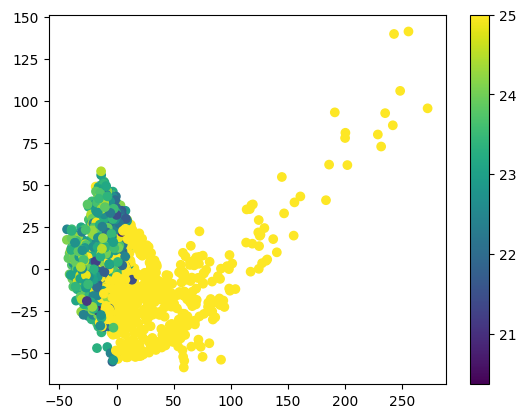

In [943]:
X = cm_desc_ase_atoms

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA(n_components=2)
pca.fit(X)
RES = pca.fit_transform(X)
s = plt.scatter(*RES.T, c=energies_df["NBOND"], vmin=energies_df["NBOND"].min(), vmax=25)
plt.colorbar(s)

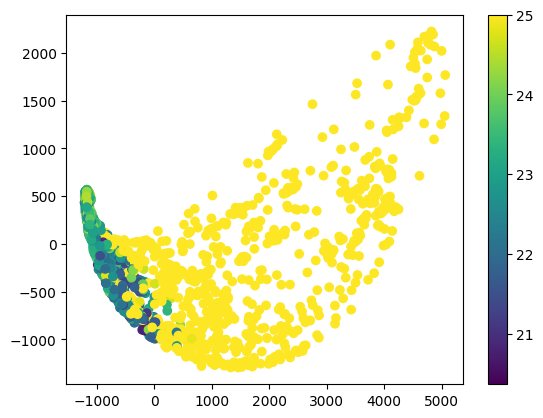

In [944]:
X = soap_ase_atoms_

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA(n_components=2)
pca.fit(X)
RES = pca.fit_transform(X)
energies_df["PCA1"] = RES.T[0]
energies_df["PCA2"] = RES.T[1]

s = plt.scatter(energies_df["PCA1"], energies_df["PCA2"], c=energies_df["NBOND"], vmin=energies_df["NBOND"].min(), vmax=25)
plt.colorbar(s)

In [948]:
_ = list(energies_df.index)[1]

pycharmm.coor.set_positions(xyzs[-1])
view_pycharmm_state()

In [203]:
cc_mol_zmat = cc_mol_xyz.to_zmat()
cc_mol_zmat

/home/ericb/mmml/.venv/lib/python3.13/site-packages/chemcoord/cartesian_coordinates/_cartesian_class_get_zmat.py:734: DeprecationWarning: Will be removed in the future. Please use give_zmat.
  warnings.warn(message, DeprecationWarning)


,atom,b,a,d,bond,angle,dihedral
0,C,origin,e_z,e_x,1.889228,98.584470,26.139833
1,Hg,0,e_z,e_x,1.080811,163.631660,21.588172
2,Cd,1,0,e_x,2.155080,34.296896,74.918688
4,Cd,2,1,0,2.427635,55.757035,-0.062261
6,Ce,4,2,1,2.803216,30.026227,-179.989888
8,Ce,6,4,2,2.426598,30.009509,179.969370
3,H,6,4,2,2.156820,85.742838,0.006889
5,H,8,6,4,2.157551,115.723836,-0.010852
7,He,6,4,2,1.080427,179.944519,-22.060589
10,C,8,6,4,1.400096,29.981888,-179.992575


In [41]:
cc_mol_zmat

,atom,b,a,d,bond,angle,dihedral
0,C,origin,e_z,e_x,1.889228,98.584470,26.139833
1,Hg,0,e_z,e_x,1.080811,163.631660,21.588172
2,Cd,1,0,e_x,2.155080,34.296896,74.918688
4,Cd,2,1,0,2.427635,55.757035,-0.062261
6,Ce,4,2,1,2.803216,30.026227,-179.989888
8,Ce,6,4,2,2.426598,30.009509,179.969370
3,H,6,4,2,2.156820,85.742838,0.006889
5,H,8,6,4,2.157551,115.723836,-0.010852
7,He,6,4,2,1.080427,179.944519,-22.060589
10,C,8,6,4,1.400096,29.981888,-179.992575


In [42]:


eq = cc_mol_xyz.symmetrize(max_n=25, tolerance=0.3, epsilon=1e-5)



In [43]:
eq

{'sym_mol':    atom         x         y         z
 0     C -4.367121  0.069928 -0.476882
 1    Hg -3.507121  0.162928 -1.124882
 2    Cd -4.242121 -0.569072  0.764118
 3     H -3.286121 -0.968072  1.074118
 4    Cd -5.607121  0.585928 -0.877882
 5     H -5.702121  1.077928 -1.835882
 6    Ce -5.358121 -0.691072  1.605118
 7    He -5.261121 -1.183072  2.562118
 8    Ce -6.722121  0.462928 -0.036882
 9    He -7.676121  0.860928 -0.346882
 10    C -6.597121 -0.175072  1.203118
 11    H -7.456121 -0.269072  1.851118
 12    C  5.632879  0.069928 -0.476882
 13   Hg  6.492879  0.163928 -1.124882
 14   Cd  5.756879 -0.569072  0.764118
 15    H  6.713879 -0.967072  1.074118
 16   Cd  4.392879  0.585928 -0.877882
 17    H  4.296879  1.077928 -1.835882
 18   Ce  4.641879 -0.691072  1.605118
 19   He  4.738879 -1.183072  2.562118
 20   Ce  3.276879  0.462928 -0.036882
 21   He  2.322879  0.861928 -0.346882
 22    C  3.401879 -0.175072  1.204118
 23    H  2.543879 -0.269072  1.851118,
 'eq_sets': {

In [44]:
eq["sym_mol"].get_pointgroup(tolerance=0.1)



C1

In [45]:
pycharmm.coor.set_positions(eq["sym_mol"])

In [46]:
view_pycharmm_state()